### Testing File

In [1]:

import warnings
import logging

# 1. Broadly ignore the dependency warnings from requests
warnings.filterwarnings("ignore", category=UserWarning, module="requests")
# 2. Specifically target the message if the category filter fails
warnings.filterwarnings("ignore", message=".*urllib3.*")
# 3. Optional: Silence the logger if it's being sent to logging instead of stdout
logging.getLogger("requests").setLevel(logging.ERROR)

# NOW do your imports
from langchain.tools import tool
from langchain.chat_models import init_chat_model

# Initialize the model, using Haiku for now, but should prob change to sonnet once things are working

model = init_chat_model("claude-haiku-4-5-20251001")

In [ ]:
# Setting up RAG and context stuff

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
import os

# persisent directory of the database
persist_directory = "./chroma_db"
source_file = "./personal_context/context.md" # location of the personal context file (markdown labeled)

# 3. Initialize BGE-M3

# This will download the model (~2GB) on the first run
model_name = "BAAI/bge-m3"
model_kwargs = {'device': 'cpu'} # Change to 'cuda' if you have a GPU
encode_kwargs = {'normalize_embeddings': True}

bge_embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

# 2. Check if DB exists
if os.path.exists(persist_directory) and os.listdir(persist_directory):
    print("--- Loading existing Vector Store ---")
    vectorstore = Chroma(
        persist_directory=persist_directory,
        embedding_function=bge_embeddings
    )
else:
    print("--- Creating new Vector Store ---")
    with open(source_file, "r") as f:
        markdown_document = f.read()
    
    headers_to_split_on = [("##", "Experience_Name")]
    markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
    md_header_splits = markdown_splitter.split_text(markdown_document)
    
    vectorstore = Chroma.from_documents(
        documents=md_header_splits, 
        embedding=bge_embeddings,
        persist_directory=persist_directory
    )

# Initialize the retriever
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 5,
        "fetch_k": 15,
        "lambda_mult": 0.5
    }
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

--- Loading existing Vector Store ---


In [3]:
# Define tools for the researcher node

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_core.tools import Tool
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from crawl4ai import AsyncWebCrawler


tavily_tool = TavilySearch(
    max_results=3,
)

@tool
async def web_crawler_tool(url: str) -> str:
    """
    Crawls a website and returns its clean markdown content. 
    Use this for extracting detailed information from job postings or company pages.
    """
    async with AsyncWebCrawler() as crawler:
        # arun fetches the page and converts it to LLM-ready markdown
        result = await crawler.arun(url=url)
        
        if result.success:
            return result.markdown
        else:
            return f"Failed to crawl {url}: {result.error_message}"


# Augment the LLM with tools

tools = [tavily_tool, web_crawler_tool]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [11]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator
from typing import List

# Build state that will be used to store everything

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]
    llm_calls: int
    job_url: str
    job_desc: str
    company_research: str
    resume_context: List[str]
    writing_sample: str
    selected_experiences: List[str]
    draft_letter: str
    critique: str
    iteration_count: int
    exception_triggered: int
    current_date: str
    cover_letter_name: str

In [12]:
from langchain.messages import SystemMessage, ToolMessage

#researcher agent

async def llm_call(state: AgentState):
    """LLM decides whether to call a tool or not"""

    prompt = [
        SystemMessage(
            content="""You are a helpful researcher tasked with using your tools to take in a given request, and 
            perform the necessary tool calls to fill out the company research and job description fields in the State. 
            Take the URL that is given to you,and perform a Crawl scrape on it, which gets saved to job_desc. Based on 
            whatever company that job description is for, then perform a Tavily search to find out general company values,
            mission statements, and beliefs that characterize the work and style of that company, this will then be saved 
            into company_research. You do not need to know the specific information extracted from either tool, that is
            handled and saved to the state by the tool itself. Proceed once both tasks are complete. Do not summarize or
            discuss what was extracted, simply call the necessary tools, and move on."""
        )
    ] + state["messages"]

    # Use ainvoke for the async call
    response = await model_with_tools.ainvoke(prompt)

    return {
        "messages": [response],
        "llm_calls": state.get('llm_calls', 0) + 1
    }


#tool node with tool calls

async def tool_node(state: AgentState):
    """Unified tool node that extracts and summarizes results directly into the state."""
    last_message = state["messages"][-1]
    tool_messages = []
    
    # Use local variables to build the update dictionary
    updated_company_research = state.get("company_research", "")
    updated_job_desc = state.get("job_desc", "")
    updated_job_url = state.get("job_url", "")

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        
        # 1. HANDLE COMPANY RESEARCH (TAVILY)
        if "tavily" in tool_name.lower():
            query = tool_call["args"].get("query", "")
            raw_result = await tavily_tool.ainvoke({"query": query})
            
            summary_prompt = f"Summarize the company values and mission from this research in 3-5 sentences. CONTENT:{raw_result}"
            summary = await model.ainvoke(summary_prompt)
            
            updated_company_research = summary.content
            tool_messages.append(ToolMessage(
                content="Company research summarized and saved.", 
                tool_call_id=tool_call["id"]
            ))

        # 2. HANDLE JOB DESCRIPTION (CRAWL4AI)
        elif tool_name == "web_crawler_tool":

            url = tool_call["args"].get("url", "")
            raw_markdown = await web_crawler_tool.ainvoke({"url": url})
            
            summary_prompt = f"""
                Extract only the job responsibilities, requirements, and benefits from the following markdown.
                Ignore navigation menus, footer links, and application form fields (dropdowns, questions).
                
                CONTENT: {raw_markdown}
                """
            summary = await model.ainvoke(summary_prompt)

            # TO DO: PROMPT AGAIN TO GENERATE AN APPROPRIATELY FORMATTED COVER LETTER NAME SO THAT IT USES IT UPON OUTPUT!!!!!
            pdf_name_prompt = f"""
            Based on the following job description content, create a title for a cover letter under the following format.
            Do not deviate from the following format, and do not include any other explanative or confirming text. Output
            ONLY the correctly formatted string:

            STRING FORMAT: "[COMPANY_NAME]_[JOB_TITLE]_Cover_Letter.pdf"

            CONTENT: {raw_markdown}
            """

            pdf_name_result = await model.ainvoke(pdf_name_prompt)
            
            updated_job_desc = summary.content
            cover_letter_name = pdf_name_result.content
            updated_job_url = url
            tool_messages.append(ToolMessage(
                content="Job description summarized and saved.", 
                tool_call_id=tool_call["id"]
            ))
            
        # 3. SAFETY FALLBACK (Prevents the 400 error)
        else:
            print("\n Entering Else Statement!")
            tool_messages.append(ToolMessage(
                content="Tool executed but result not summarized.", 
                tool_call_id=tool_call["id"]
            ))

    return {
        "company_research": updated_company_research,
        "job_desc": updated_job_desc,
        "job_url": updated_job_url,
        "cover_letter_name": cover_letter_name,
        "messages": tool_messages
    }

In [13]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_core.messages import HumanMessage, AIMessage
import os

async def context_engine_node(state: AgentState):
    """
    Combined node: Retrieves context from RAG & MCP, then selects the best 
    experiences to highlight based on the job description.
    """
    job_requirements = state["job_desc"]
    
    # --- STEP 1: RAG RETRIEVAL ---

    # Find experiences in your resumes that match the job description
    relevant_docs = await retriever.ainvoke(job_requirements)

    # FORCE UNIQUENESS: Use a set to track content we've already seen
    unique_content = []
    seen = set()
    for doc in relevant_docs:
        # Use a hash or just the text to check for duplicates
        content = doc.page_content.strip()
        if content not in seen:
            unique_content.append(content)
            seen.add(content)
    
    # Ensure we only present the unique ones to the LLM
    raw_blocks = unique_content[:5]
    resume_text = "\n\n".join([doc.page_content for doc in relevant_docs])
            
    # --- STEP 2: EXTRACT SAMPLE LETTER ---

    try:
        sample_path = os.path.join("./personal_context/samples", "sample_cover_letter.txt")
        with open(sample_path, "r") as f:
            writing_style = f.read()
    except Exception as e:
        writing_style = f"Fallback style: Professional and technical. Error: {str(e)}"

    # --- STEP 3: EXACT EXPERIENCE SELECTION ---
    # Create an enumerated list for the LLM to choose from
    formatted_options = "\n\n".join([f"--- ID: {i} ---\n{content}" for i, content in enumerate(raw_blocks)])

    selection_prompt = f"""
        You are a Career Strategist.
        
        TARGET JOB REQUIREMENTS:
        {job_requirements}
        
        AVAILABLE PERSONAL EXPERIENCES:
        {formatted_options}
        
        TASK:
        Identify the IDs of the 2-3 most relevant experiences that best match the job requirements.
        Return ONLY the IDs as a comma-separated list (e.g., 0, 2). Do not include any text.
        """

    id_response = await model.ainvoke(selection_prompt)

    try:
        # Parse the IDs and strip any whitespace/extra characters
        selected_ids = [int(i.strip()) for i in id_response.content.split(",") if i.strip().isdigit()]
        
        # Map the IDs back to the EXACT raw text from RAG
        selected_experiences = [raw_blocks[i] for i in selected_ids if i < len(raw_blocks)]
        exception_trig = 0
    except Exception as e:
        # Fallback: if LLM fails formatting, take the first 2 blocks
        print("LLM Failed formatting!!")
        exception_trig = 1
        selected_experiences = raw_blocks[:2]


    return {
        "resume_context": [resume_text],
        "writing_sample": writing_style,
        "selected_experiences": selected_experiences,
        "exception_triggered": exception_trig,
        "messages": [AIMessage(content=f"Strategist: Selected {len(selected_experiences)} key experiences.")]
    }

In [14]:
async def cl_writer_node(state: AgentState):
    """Few shot prompt node that takes in a bunch of information from the state, 
    and returns an initial draft of the cover letter in my writing style, using
    the selected experiences from the context engine, and writing sample from the 
    filesystem. 
    """
    job_desc = state["job_desc"]
    company_research = state["company_research"] 
    resume_context = state["resume_context"]
    style_sample = state["writing_sample"]
    experiences = "\n\n".join(state["selected_experiences"])
    current_date = state["current_date"]


    writer_prompt = f"""
    You are Ruben Fonseca, a robotics engineer with an MS from UMich and a BS from Harvard. 
    Your task is to write a highly tailored cover letter for a given job description/posting
    based on the resume context, selected experiences, and writing sample in Ruben's style. You
    are to mimic his writing style, and copy the overall paragraph structure of the style sample.
    The style sample includes [] brackets with descriptive information that must be filled it based
    on the information provided to you. For the first and fourth body paragraphs, besides those bracketed fill in
    sections, do not change the wording/sentences. For the second and third body paragraphs, treat the style sample as
    purely a style sample, and instead replace them with similarly lengthed paragraphs that discuss the 2-3 specific
    experiences that are highlighted, and tie them to the job requirements, or overall company values as best as possible,
    again using Ruben's writing style.

    STRICT STYLE GUIDE (Mimic this):
    {style_sample}

    TARGET JOB REQUIREMENTS:
    {job_desc}

    TARGET COMPANY RESEARCH (Incorporate these values):
    {company_research}

    SPECIFIC EXPERIENCES TO HIGHLIGHT (Use these exact technical details and do not extrapolate):
    {experiences}

    INSTRUCTIONS:
    1. Match the technical depth and professional yet accessible tone of the style sample.
    2. Bridge the 'Specific Experiences' directly to the 'Job Requirements' and/or 'Company Research.'
    3. Keep it to one page (approx 300-400 words), as in stay around the same length as the style sample.
    4. Maintain the style sample's paragraph structure, and the preamble with date and company name.
    5. Use '{current_date}' as the date in the cover letter header.
    6. ONLY include the letter content. Do NOT include any additional text, or confirmation messages of the task being complete.

    Based on the information provided and further instructions above, output the final cover letter draft in this 
    exact format:

    OUTPUT STRUCTURE TEMPLATE (YOU MUST FOLLOW THIS EXACTLY, DON"T FORGET TO INCLUDE THE # MARKDOWN ELEMENTS):
    # [today's date]
    # [Company Name]
    # [Company City, State]
    
    ## Dear [COMPANY NAME] Recruitment Team,

    [Paragraph 1: reference the writing sample for specific content formatting]

    [Paragraph 2: reference the writing sample for specific content formatting]

    [Paragraph 3: reference the writing sample for specific content formatting]

    [Paragraph 4: reference the writing sample for specific content formatting]
    
    ### Sincerely,
    ### Ruben Fonseca
    """

    cover_letter = await model.ainvoke(writer_prompt)

    return {
        "draft_letter": cover_letter.content,
        "messages": [AIMessage(content=f"Cover Letter Draft created and saved to appropriate state.")]
    }

In [ ]:
from markdown_pdf import MarkdownPdf, Section

async def pdf_generator_node(state: AgentState):
    """
    Converts a cover letter to a PDF file.
    """

    output_dir = "./output_letters"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Format the letter
    draft = state['draft_letter']

    css_style = """
        @page { margin: 1in; }
        body {
            font-family: "Times New Roman", Times, serif;
            font-size: 12pt;
            line-height: 1.4;
            text-align: justify;
        }
        
        /* 1. Address Block (h1) */
        h1 {
            font-size: 12pt;
            font-weight: normal;
            margin: 0; /* Keeps the address lines tight */
            padding: 0;
            text-indent: 0px !important;
            text-align: left;
        }
        
        /* 2. Salutation (h2) */
        h2 {
            font-size: 12pt;
            font-weight: normal;
            margin-top: 20px; /* GAP BETWEEN ADDRESS AND DEAR */
            margin-bottom: 10px; /* Gap before the first paragraph */
            text-indent: 0px !important;
            text-align: left;
        }
        
        /* 3. Body Paragraphs */
        p {
            text-indent: 35px; /* Only indents the actual body */
            margin-top: 8px;
            margin-bottom: 0px;
        }
        
        /* 4. Signature Block (h3) */
        h3 {
            font-size: 12pt;
            font-weight: normal;
            margin: 0; /* Keeps 'Sincerely' and your Name tight */
            text-indent: 0px !important;
            text-align: left;
        }
        h3:first-of-type {
            margin-top: 25px; /* GAP BETWEEN LAST PARAGRAPH AND SINCERELY */
        }
    """

    # 4. Initialize PDF Generator
    pdf = MarkdownPdf(toc_level=0)
    pdf.add_section(
        Section(draft), 
        user_css=css_style # Pass CSS here, NOT in Section()
    )

    # 5. Save the PDF
    file_name = state['cover_letter_name']
    # file_name = f"Cover_Letter_test.pdf"
    file_path = os.path.join(output_dir, file_name)
    pdf.save(file_path)

    return {
        "messages": [AIMessage(content=f"Cover Letter converted and saved as PDF. Objective Completed.")]
    }

In [ ]:
## EXPLORE THE MULTI-MODAL AGENTIC REVISER (1-2 iterations MAX)
# first draft already does a good job, should mainly focus on checking pdf formatting

async def agentic_reviser_node(agent: AgentState):
    """
    Agentic reviser node that takes in the current draft of the cover letter, generates a pdf, evaluates the pdf multimodally,
    then observes if it has to change the formatting/writing at all to fit satisfactory guidelines.

    If there's nothing to fix on the current version of the pdf (or if iterations reach n=2, save the final pdf (scrap the draft ones?))
    """


    

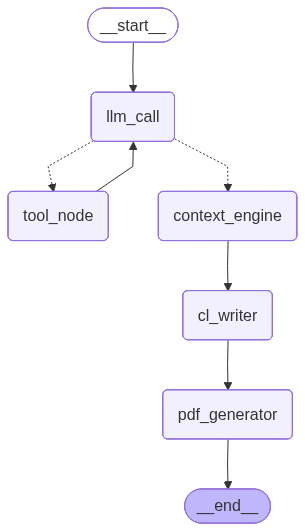

In [ ]:
from langgraph.graph import StateGraph, START, END

agent_builder = StateGraph(AgentState)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)  # Single unified node
agent_builder.add_node("context_engine",context_engine_node) # with RAG and FileSystem MCP
agent_builder.add_node("cl_writer",cl_writer_node)
agent_builder.add_node("pdf_generator",pdf_generator_node)

def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return "context_engine"
    return "tool_node"

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", "context_engine"]
)
agent_builder.add_edge("tool_node", "llm_call")
agent_builder.add_edge("context_engine","cl_writer")
agent_builder.add_edge("cl_writer","pdf_generator")
agent_builder.add_edge("pdf_generator",END)

agent = agent_builder.compile()

#display graph for debugging purposes/flow

from IPython.display import Image, display
try:
    display(Image(agent.get_graph(xray=True).draw_mermaid_png()))
except:
    pass

In [17]:
# Invoke/Attempt flow

from langchain.messages import HumanMessage
from datetime import datetime

# Get the actual current date in a professional format
today = datetime.now().strftime("%B %d, %Y")

url = "https://job-boards.greenhouse.io/figureai/jobs/4609306006"

request = [HumanMessage(content=f"Scrape the listing from this website: {url}. Also extract the company information of that listing")]

initial_state = {
    "messages": request,
    "current_date": today  
}

messages = await agent.ainvoke(initial_state)
for m in messages["messages"]:
    m.pretty_print()

[INIT].... → Crawl4AI 0.8.0 

[FETCH]... ↓ https://job-boards.greenhouse.io/figureai/jobs/4609306006                                            |
✓ | ⏱: 6.12s 

[SCRAPE].. ◆ https://job-boards.greenhouse.io/figureai/jobs/4609306006                                            |
✓ | ⏱: 0.22s 

[COMPLETE] ● https://job-boards.greenhouse.io/figureai/jobs/4609306006                                            |
✓ | ⏱: 6.38s 

================================ Human Message =================================

Scrape the listing from this website: https://job-boards.greenhouse.io/figureai/jobs/4609306006. Also extract the company information of that listing
================================== Ai Message ==================================

[{'text': "I'll scrape the job listing and gather company information for you.", 'type': 'text'}, {'id': 'toolu_01RQQFgnqcKRxMDF3hXFVTuM', 'caller': {'type': 'direct'}, 'input': {'url': 'https://job-boards.greenhouse.io/figureai/jobs/4609306006'}, 'name': 'web_crawler_tool', 'type': 'tool_use'}, {'id': 'toolu_018qmq9C7CwLuqfr13iNAHDH', 'caller': {'type': 'direct'}, 'input': {'query': 'Figure AI company mission values beliefs', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}]
Tool Calls:
  web_crawler_tool (toolu_01RQQFgnqcKRxMDF3hXFVTuM)
 Call ID: toolu_01RQQFgnqcKRxMDF3hXFVTuM
  Args:
    url: https://job-boards.greenhouse.io/figureai/jobs/4609306006


In [19]:
#evaluate output/debugging cell

import textwrap

print("Exception Triggered: " + str(messages["exception_triggered"]) + "\n")
print("pdf name: " + str(messages["cover_letter_name"]) + "\n")
print("Resume Context: \n" + messages["resume_context"][0] + "\n")

selected_exp_lists = messages["selected_experiences"]

print("Selected_exp element: \n" + textwrap.fill(selected_exp_lists[0], width=60))

print("Writing Sample: \n" + messages["writing_sample"] + "\n")

print("Cover Letter Draft: \n" + messages["draft_letter"])

Exception Triggered: 0

pdf name: Figure_Middleware_Software_Engineer_Cover_Letter.pdf

Resume Context: 
Details: Spearheaded the controls and communications framework for a wheeled-quadruped robot, including low-level CAN firmware, Forward and Inverse Kinematics, dynamically-aware Task-Space Control (TSC), dynamics modeling, and multi-threaded control firmware development in C/C++. Led a team of 4, delegated minor tasks to undergraduates, and drove progress from motor firmware interpretation and connection to TSC/multi-motor control. Certain closed-loop control systems were intermediately implemented among the primary systems for functionality validation, including virtual spring/damper systems, both for single motor and joint motor configurations, virtual walls, and gravity compensation demos for the leg. Maintained up-to-date and detailed documentation that was later used to onboard new members, and pass on the project to a new graduate student lead after my graduation. Presently pr

In [ ]:
messages["draft_letter"]

"# March 10, 2026\n# Figure AI\n# San Jose, CA\n\n## Dear Figure AI Recruitment Team,\n\nMy name is Ruben Fonseca, and I am a recent Harvard mechanical engineering graduate and just graduated from the University of Michigan with a M.S. in Robotics. I am writing to apply for the Middleware Software Engineer position. The field of humanoid robotics and autonomous systems are what inspired me to pursue engineering, and Figure AI's vision of deploying general-purpose humanoid robots to solve challenges within the labor economy is something that deeply resonates with my own personal motivations in engineering. I would welcome the opportunity to contribute through my technical skills, teamwork and communication skills, and past experiences in building robust, production-grade software systems.\n\nI have developed extensive expertise in the systems-level C/C++ middleware and real-time control frameworks that are central to this role. Spearheading the controls and communications framework for 